# Lab #04: 머신러닝 기초 (Basics of Machine Learning)

**딥러닝 응용 (Deep Learning Application)**  
국립금오공과대학교 산업·빅데이터공학부 | 추상현

---

## 목차

| 파트 | 주제 | 내용 |
|:---:|:---|:---|
| **Part 1** | 머신러닝이란? | AI/ML/DL 관계, ML 유형, Classification vs Regression |
| **Part 2** | 모델 평가와 일반화 | Train/Test, Overfitting, Regularization, CV |
| **Part 3** | 지도학습 알고리즘 | KNN, Logistic Regression |
| **Part 4** | 경사 하강법 | GD 원리, Learning Rate, 최적화 알고리즘 |

---

## 🎯 학습 목표 (Learning Objectives)

- 머신러닝의 정의와 유형 이해
- 데이터 분할, 일반화, 과적합 개념 학습
- KNN, Logistic Regression 알고리즘 실습
- 경사 하강법의 원리 이해 및 구현
- scikit-learn과 PyTorch를 활용한 ML 파이프라인 구성

---
# Part 1: 머신러닝이란? (What is Machine Learning?)
---

## 1.1 AI, ML, DL의 관계

인공지능(AI), 머신러닝(ML), 딥러닝(DL), 생성형 AI(Generative AI)는 서로 **포함 관계**를 가집니다.

$$\text{AI} \supset \text{ML} \supset \text{DL} \supset \text{Generative AI}$$

| 분야 | 설명 | 핵심 키워드 |
|:---|:---|:---|
| **AI (Artificial Intelligence)** | 인간의 지능을 모방하는 시스템 | 규칙 기반, 전문가 시스템 |
| **ML (Machine Learning)** | 데이터로부터 학습하는 알고리즘 | 패턴 인식, 통계적 학습 |
| **DL (Deep Learning)** | 다층 신경망을 사용하는 ML의 하위 분야 | 신경망, 표현 학습 |
| **Generative AI** | 새로운 콘텐츠를 생성하는 AI | LLM, 이미지 생성 |

### 머신러닝의 정의

> **Arthur Samuel (1959):** "명시적으로 프로그래밍하지 않고도 컴퓨터가 학습할 수 있도록 하는 연구 분야"  
> *"Field of study that gives computers the ability to learn without being explicitly programmed."*

> **Tom Mitchell (1998):** "컴퓨터 프로그램이 경험 E로부터 과제 T에 대한 성능 P가 향상된다면, 그 프로그램은 학습한 것이다."  
> *"A computer program is said to learn from experience E with respect to some task T and performance measure P, if its performance at task T, as measured by P, improves with experience E."*

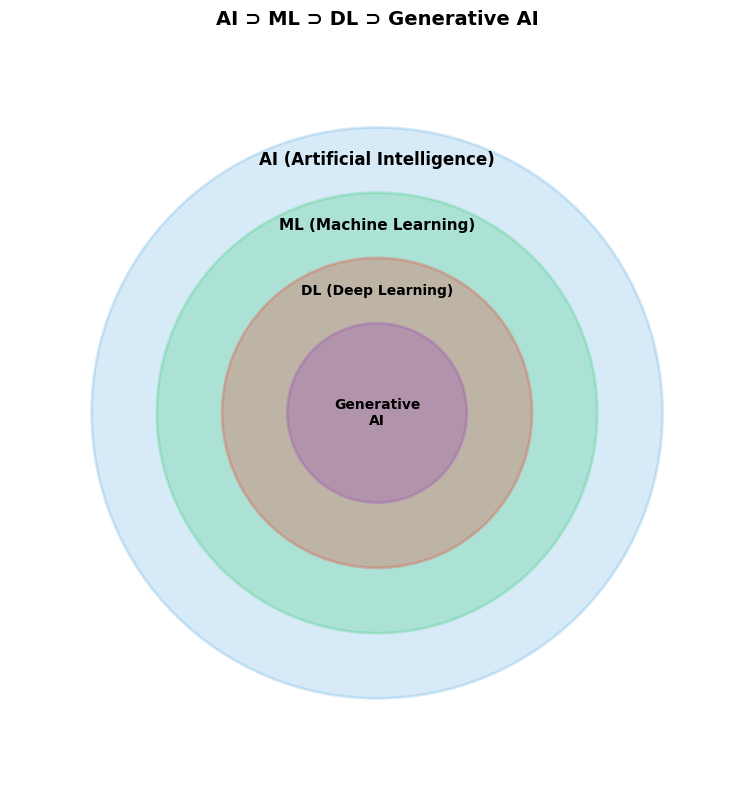

In [1]:
# AI > ML > DL > Generative AI 네스티드 원 다이어그램
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# 네스티드 원 (바깥에서 안쪽으로)
circles = [
    {'r': 3.5, 'label': 'AI\n(Artificial Intelligence)', 'color': '#3498db', 'alpha': 0.2},
    {'r': 2.7, 'label': 'ML\n(Machine Learning)', 'color': '#2ecc71', 'alpha': 0.25},
    {'r': 1.9, 'label': 'DL\n(Deep Learning)', 'color': '#e74c3c', 'alpha': 0.3},
    {'r': 1.1, 'label': 'Generative\nAI', 'color': '#9b59b6', 'alpha': 0.35},
]

for c in circles:
    circle = plt.Circle((0, 0), c['r'], color=c['color'], alpha=c['alpha'], ec=c['color'], lw=2)
    ax.add_patch(circle)

# 레이블
ax.text(0, 3.1, 'AI (Artificial Intelligence)', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0, 2.3, 'ML (Machine Learning)', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(0, 1.5, 'DL (Deep Learning)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(0, 0, 'Generative\nAI', ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.set_title('AI ⊃ ML ⊃ DL ⊃ Generative AI', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.2 머신러닝의 유형

머신러닝은 학습 방식에 따라 크게 4가지 유형으로 나눌 수 있습니다.

| 유형 | 설명 | 데이터 | 예시 |
|:---|:---|:---|:---|
| **Supervised Learning** (지도학습) | 입력-출력 쌍으로 학습 | 레이블 O | 스팸 분류, 집값 예측 |
| **Unsupervised Learning** (비지도학습) | 패턴/구조 발견 | 레이블 X | 고객 세분화, 차원 축소 |
| **Semi-supervised Learning** (준지도학습) | 소량 레이블 + 대량 비레이블 | 일부 레이블 | 의료 이미지 분류 |
| **Reinforcement Learning** (강화학습) | 환경과 상호작용, 보상 최대화 | 보상 신호 | 게임, 로봇, 자율주행 |

### 🔗 AI 연결: 실제 서비스에서의 ML 유형

우리가 매일 사용하는 서비스들이 어떤 ML 유형을 활용하는지 살펴봅시다.

In [2]:
# 실제 서비스에서의 ML 유형 사례
ml_examples = {
    'Supervised Learning': [
        '이메일 스팸 필터링 (Gmail)',
        '음성 인식 (Siri, Google Assistant)',
        '이미지 분류 (Google Photos)',
        '번역 (Google Translate)',
    ],
    'Unsupervised Learning': [
        '고객 세분화 (마케팅)',
        '이상 탐지 (신용카드 사기 감지)',
        '추천 시스템의 사용자 군집화 (Netflix)',
        '토픽 모델링 (뉴스 기사 분류)',
    ],
    'Semi-supervised Learning': [
        '의료 이미지 진단 (소량의 전문가 레이블)',
        '웹 콘텐츠 분류',
        '음성 데이터 전사 (소량 전사 + 대량 음성)',
    ],
    'Reinforcement Learning': [
        '게임 AI (AlphaGo, Atari)',
        '자율 주행 (Waymo, Tesla)',
        '로봇 제어',
        'ChatGPT의 RLHF (인간 피드백 강화학습)',
    ]
}

for ml_type, examples in ml_examples.items():
    print(f"\n📌 {ml_type}")
    for ex in examples:
        print(f"   • {ex}")


📌 Supervised Learning
   • 이메일 스팸 필터링 (Gmail)
   • 음성 인식 (Siri, Google Assistant)
   • 이미지 분류 (Google Photos)
   • 번역 (Google Translate)

📌 Unsupervised Learning
   • 고객 세분화 (마케팅)
   • 이상 탐지 (신용카드 사기 감지)
   • 추천 시스템의 사용자 군집화 (Netflix)
   • 토픽 모델링 (뉴스 기사 분류)

📌 Semi-supervised Learning
   • 의료 이미지 진단 (소량의 전문가 레이블)
   • 웹 콘텐츠 분류
   • 음성 데이터 전사 (소량 전사 + 대량 음성)

📌 Reinforcement Learning
   • 게임 AI (AlphaGo, Atari)
   • 자율 주행 (Waymo, Tesla)
   • 로봇 제어
   • ChatGPT의 RLHF (인간 피드백 강화학습)


### 📝 실습 1-1 [초급] ML 유형 분류하기

아래 시나리오들을 읽고, 각각 어떤 머신러닝 유형에 해당하는지 분류하세요.

선택지: `"supervised"`, `"unsupervised"`, `"semi-supervised"`, `"reinforcement"`

In [3]:
# 실습 1-1: 빈칸을 채우세요
# 각 시나리오에 맞는 ML 유형을 문자열로 입력하세요.

scenarios = {
    '10만 장의 레이블된 고양이/개 사진으로 분류기 학습': "supervised",  # "supervised" 또는 "unsupervised" 등
    '구매 이력으로 고객을 자동 군집화':"unsupervised",
    '로봇이 시행착오를 통해 걷는 법을 학습': "reinforcement",
    '100장의 레이블 X-ray + 10만장의 비레이블 X-ray로 질병 분류': "semi-supervised",
    '과거 주가 데이터로 내일 주가 예측': "supervised",
}

# 검증
assert scenarios['10만 장의 레이블된 고양이/개 사진으로 분류기 학습'] == 'supervised'
assert scenarios['구매 이력으로 고객을 자동 군집화'] == 'unsupervised'
assert scenarios['로봇이 시행착오를 통해 걷는 법을 학습'] == 'reinforcement'
assert scenarios['100장의 레이블 X-ray + 10만장의 비레이블 X-ray로 질병 분류'] == 'semi-supervised'
assert scenarios['과거 주가 데이터로 내일 주가 예측'] == 'supervised'

print("\n✅ 모든 테스트 통과!")


✅ 모든 테스트 통과!


## 1.3 지도학습: Classification vs Regression

지도학습은 출력(Target)의 유형에 따라 **분류(Classification)**와 **회귀(Regression)**로 나뉩니다.

| | Classification (분류) | Regression (회귀) |
|:---|:---|:---|
| **출력** | 범주(카테고리) | 연속적인 숫자 |
| **예시** | 스팸/정상, 개/고양이 | 집값, 온도 예측 |
| **평가 지표** | Accuracy, F1-Score | MSE, R² |
| **알고리즘** | KNN, Logistic Reg, SVM | Linear Reg, Ridge, Lasso |

### Binary vs Multi-class Classification

- **Binary Classification** (이진 분류): 두 개의 클래스 (예: 양성/음성, 스팸/정상)
- **Multi-class Classification** (다중 클래스 분류): 세 개 이상의 클래스 (예: 숫자 0~9 인식, 동물 종류 분류)

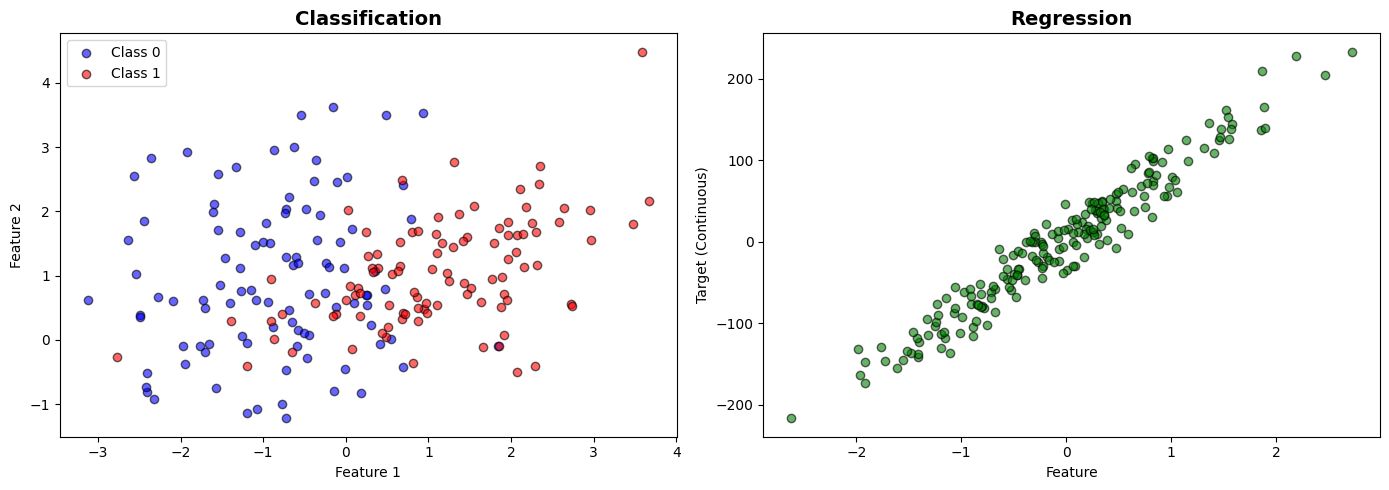

In [5]:
# Classification vs Regression 데이터 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification 데이터
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=42)
axes[0].scatter(X_cls[y_cls==0, 0], X_cls[y_cls==0, 1], c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_cls[y_cls==1, 0], X_cls[y_cls==1, 1], c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[0].set_title('Classification', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

# Regression 데이터
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
axes[1].scatter(X_reg, y_reg, c='green', alpha=0.6, edgecolors='k')
axes[1].set_title('Regression', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Target (Continuous)')

plt.tight_layout()
plt.show()

### 📝 실습 1-2 [초급] 데이터셋 보고 문제 유형 판별

아래 데이터셋 설명을 읽고, **분류(classification)** 문제인지 **회귀(regression)** 문제인지 판별하세요.

In [6]:
# 실습 1-2: 빈칸을 채우세요
# 각 데이터셋에 대해 "classification" 또는 "regression"을 입력하세요.

datasets = {
    '환자의 증상 데이터로 질병 유무 진단': 'classification',
    '집의 면적, 위치 등으로 집값 예측': 'regression',
    '이메일 텍스트로 스팸/정상 분류': 'classification',
    '학생의 공부시간으로 시험 점수 예측': 'regression',
    '손글씨 이미지를 0~9 숫자로 인식': 'classification',
}

# 검증
assert datasets['환자의 증상 데이터로 질병 유무 진단'] == 'classification'
assert datasets['집의 면적, 위치 등으로 집값 예측'] == 'regression'
assert datasets['이메일 텍스트로 스팸/정상 분류'] == 'classification'
assert datasets['학생의 공부시간으로 시험 점수 예측'] == 'regression'
assert datasets['손글씨 이미지를 0~9 숫자로 인식'] == 'classification'

print("\n✅ 모든 테스트 통과!")


✅ 모든 테스트 통과!


---
# Part 2: 모델 평가와 일반화 (Model Evaluation & Generalization)
---

## 2.1 Training vs Test Data

### 왜 데이터를 나누는가?

머신러닝의 궁극적 목표는 **학습에 사용하지 않은 새로운 데이터**에서도 좋은 성능을 보이는 것입니다.  
이를 **일반화(Generalization)** 능력이라고 합니다.

| 개념 | 설명 |
|:---|:---|
| **Training Error** | 학습 데이터에서의 오류 |
| **Test Error (Generalization Error)** | 학습에 사용하지 않은 데이터에서의 오류 |

**목표:**
1. Training Error를 작게 만든다
2. Training Error와 Test Error의 격차(gap)를 작게 만든다

In [7]:
# Training vs Test Error 비교
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 데이터 생성
np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# 데이터 분할 (70% 학습, 30% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 및 에러 계산
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print(f"📊 데이터 크기: 전체 {len(X)}, 학습 {len(X_train)}, 테스트 {len(X_test)}")
print(f"\n🔵 Training MSE: {train_mse:.2f}")
print(f"🔴 Test MSE:     {test_mse:.2f}")
print(f"\n📈 Train-Test Gap: {abs(test_mse - train_mse):.2f}")

📊 데이터 크기: 전체 200, 학습 140, 테스트 60

🔵 Training MSE: 217.47
🔴 Test MSE:     261.57

📈 Train-Test Gap: 44.10


### 📝 실습 2-1 [초급] 데이터 분할 및 에러 비교

`make_classification` 데이터를 생성하고, `train_test_split`으로 분할한 뒤, `LogisticRegression`으로 학습하여 Training/Test Accuracy를 비교하세요.

In [ ]:
# 실습 2-1: 빈칸을 채우세요
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 데이터 생성
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)

# 데이터 분할 (test_size를 0.3으로 설정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(____, ____)

# 정확도 평가
train_acc = model.score(____, ____)
test_acc = model.score(____, ____)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# 검증
assert 0.7 < train_acc <= 1.0, f"Training accuracy가 예상 범위를 벗어났습니다: {train_acc}"
assert 0.7 < test_acc <= 1.0, f"Test accuracy가 예상 범위를 벗어났습니다: {test_acc}"
assert len(X_train) == 350, f"Training 데이터 크기가 맞지 않습니다: {len(X_train)}"
assert len(X_test) == 150, f"Test 데이터 크기가 맞지 않습니다: {len(X_test)}"

print("\n✅ 모든 테스트 통과!")

## 2.2 Overfitting과 Underfitting

모델의 복잡도(Complexity)에 따라 **과소적합(Underfitting)**과 **과적합(Overfitting)** 문제가 발생할 수 있습니다.

| | Underfitting (과소적합) | Just Right (적절) | Overfitting (과적합) |
|:---|:---|:---|:---|
| **모델 복잡도** | 너무 단순 | 적절 | 너무 복잡 |
| **Bias** | 높음 (High Bias) | 적절 | 낮음 |
| **Variance** | 낮음 | 적절 | 높음 (High Variance) |
| **Training Error** | 높음 | 낮음 | 매우 낮음 |
| **Test Error** | 높음 | 낮음 | 높음 |
| **특징** | 데이터의 패턴을 학습 못함 | 일반화 능력 좋음 | 노이즈까지 학습 |

> **핵심:** 적절한 모델 복잡도를 찾는 것이 머신러닝의 핵심 과제입니다.

In [ ]:
# 다항 회귀로 Underfitting, Just Right, Overfitting 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 노이즈가 있는 sin 곡선 데이터 생성
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.uniform(0, 1, n_samples))
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.3, n_samples)
X = X.reshape(-1, 1)

# Train/Test 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 시각화를 위한 X 범위
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

degrees = [1, 3, 15]
titles = ['Underfitting\n(degree=1)', 'Just Right\n(degree=3)', 'Overfitting\n(degree=15)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, degree, title in zip(axes, degrees, titles):
    # 파이프라인: 다항 변환 → 선형 회귀
    pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipeline.fit(X_train, y_train)

    # 예측
    y_plot = pipeline.predict(X_plot)
    train_mse = mean_squared_error(y_train, pipeline.predict(X_train))
    test_mse = mean_squared_error(y_test, pipeline.predict(X_test))

    # 시각화
    ax.scatter(X_train, y_train, c='blue', label='Train', zorder=3, edgecolors='k', alpha=0.7)
    ax.scatter(X_test, y_test, c='red', label='Test', zorder=3, edgecolors='k', alpha=0.7)
    ax.plot(X_plot, y_plot, 'g-', linewidth=2, label=f'Model (deg={degree})')
    ax.set_title(f'{title}\nTrain MSE: {train_mse:.3f} | Test MSE: {test_mse:.3f}', fontsize=11)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔗 AI 연결: 모델 복잡도 vs 일반화 트레이드오프

딥러닝에서도 과적합은 매우 중요한 문제입니다. 다음과 같은 기법으로 과적합을 방지합니다:

| 기법 | 설명 |
|:---|:---|
| **Dropout** | 학습 중 랜덤하게 뉴런을 비활성화 |
| **Early Stopping** | 검증 손실이 증가하면 학습 중단 |
| **Data Augmentation** | 데이터를 변형하여 학습 데이터 증가 |
| **Weight Decay (L2)** | 가중치를 작게 유지하는 정규화 |
| **Batch Normalization** | 각 층의 입력을 정규화 |

이 기법들은 이후 딥러닝 파트에서 자세히 다룹니다.

### 📝 실습 2-2 [중급] 다항 차수 변화에 따른 Overfitting 관찰

다항 회귀의 차수(degree)를 변화시키면서 Training/Test MSE를 기록하고, 과적합이 발생하는 지점을 관찰하세요.

In [ ]:
# 실습 2-2: 빈칸을 채우세요
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# 데이터 생성
np.random.seed(42)
X = np.sort(np.random.uniform(0, 1, 30)).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + np.random.normal(0, 0.3, 30)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = [1, 2, 3, 5, 10, 20]
train_errors = []
test_errors = []

for degree in degrees:
    # 파이프라인 생성 (빈칸: PolynomialFeatures의 degree 설정)
    pipeline = make_pipeline(PolynomialFeatures(degree=____), LinearRegression())

    # 학습 (빈칸: fit 호출)
    pipeline.fit(____, ____)

    # 예측 (빈칸: predict 호출)
    train_pred = pipeline.predict(____)
    test_pred = pipeline.predict(____)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print(f"Degree {degree:2d}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

# 시각화: Train/Test Error 곡선
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'bo-', label='Training MSE', linewidth=2, markersize=8)
plt.plot(degrees, test_errors, 'ro-', label='Test MSE', linewidth=2, markersize=8)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Training/Test Error vs Polynomial Degree', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# 검증: degree가 높을수록 train error가 작아지는 경향
assert train_errors[0] > train_errors[-1], "Degree가 높을수록 Training Error가 작아져야 합니다"
assert len(train_errors) == 6
assert len(test_errors) == 6

print("\n✅ 모든 테스트 통과!")

## 2.3 Regularization (정규화)

**정규화(Regularization)**는 과적합을 방지하기 위해 모델의 복잡도를 제한하는 기법입니다.

### L2 정규화 (Ridge Regression)

$$\text{Loss} = \text{MSE} + \lambda \sum_{i} w_i^2$$

가중치의 **제곱합**을 패널티로 추가합니다. 가중치를 전체적으로 작게 만듭니다.

### L1 정규화 (Lasso Regression)

$$\text{Loss} = \text{MSE} + \lambda \sum_{i} |w_i|$$

가중치의 **절대값 합**을 패널티로 추가합니다. 일부 가중치를 정확히 0으로 만들어 **특징 선택(Feature Selection)** 효과가 있습니다.

> **핵심:** $\lambda$ (alpha)가 클수록 가중치를 더 작게 제한 → 모델이 더 단순해짐

In [ ]:
# Ridge 정규화로 과적합 방지 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 데이터 생성
np.random.seed(42)
X = np.sort(np.random.uniform(0, 1, 30)).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + np.random.normal(0, 0.3, 30)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

# 높은 차수(degree=15)의 다항 회귀 + Ridge
degree = 15
alphas = [0, 0.01, 1.0]
titles = ['No Regularization\n(alpha=0)', 'Ridge (alpha=0.01)', 'Ridge (alpha=1.0)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, alpha, title in zip(axes, alphas, titles):
    if alpha == 0:
        from sklearn.linear_model import LinearRegression
        pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    else:
        pipeline = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))

    pipeline.fit(X_train, y_train)
    y_plot = pipeline.predict(X_plot)

    train_mse = mean_squared_error(y_train, pipeline.predict(X_train))
    test_mse = mean_squared_error(y_test, pipeline.predict(X_test))

    ax.scatter(X_train, y_train, c='blue', label='Train', zorder=3, edgecolors='k', alpha=0.7)
    ax.scatter(X_test, y_test, c='red', label='Test', zorder=3, edgecolors='k', alpha=0.7)
    ax.plot(X_plot, y_plot, 'g-', linewidth=2, label='Model')
    ax.set_title(f'{title}\nTrain: {train_mse:.3f} | Test: {test_mse:.3f}', fontsize=10)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Ridge Regularization on Degree=15 Polynomial', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 실습 2-3 [중급] 정규화 강도에 따른 모델 변화 관찰

Ridge Regression의 `alpha` 값을 변화시키면서 Train/Test MSE를 기록하고, 최적의 alpha를 찾으세요.

In [ ]:
# 실습 2-3: 빈칸을 채우세요
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 데이터 생성
np.random.seed(42)
X = np.sort(np.random.uniform(0, 1, 30)).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + np.random.normal(0, 0.3, 30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
degree = 15
results = {}

for alpha in alphas:
    # Ridge 파이프라인 생성 (빈칸: Ridge의 alpha 설정)
    pipeline = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=____))

    # 학습
    pipeline.fit(____, ____)

    # MSE 계산
    train_mse = mean_squared_error(y_train, pipeline.predict(X_train))
    test_mse = mean_squared_error(y_test, pipeline.predict(____))

    results[alpha] = {'train_mse': train_mse, 'test_mse': test_mse}
    print(f"Alpha = {alpha:6.3f}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

# 최적 alpha 찾기 (Test MSE가 가장 작은 alpha)
best_alpha = min(results, key=lambda a: results[a]['test_mse'])
print(f"\n🏆 최적 Alpha: {best_alpha}")

# 검증
assert len(results) == 5, "5개의 alpha에 대해 모두 결과가 있어야 합니다"
assert best_alpha in alphas, "최적 alpha가 목록에 있어야 합니다"
assert all(results[a]['train_mse'] >= 0 for a in alphas), "MSE는 0 이상이어야 합니다"

print("\n✅ 모든 테스트 통과!")

## 2.4 Hyperparameters vs Parameters

| | Parameters (파라미터) | Hyperparameters (하이퍼파라미터) |
|:---|:---|:---|
| **정의** | 학습 과정에서 데이터로부터 학습 | 학습 전에 사람이 설정 |
| **예시** | Weights, Biases | Learning Rate, Regularization 강도, K값 |
| **결정 방법** | 학습 알고리즘이 자동 결정 | 사람 또는 탐색 알고리즘이 결정 |
| **영향** | 모델의 예측 | 학습 과정 자체를 제어 |

### Validation Set의 역할

하이퍼파라미터를 Test Set으로 튜닝하면, Test Set에 과적합될 수 있습니다.  
따라서 **Validation Set**을 별도로 분리하여 하이퍼파라미터 튜닝에 사용합니다.

```
전체 데이터
├── Training Set (70%)   → 모델 학습
├── Validation Set (15%) → 하이퍼파라미터 튜닝
└── Test Set (15%)       → 최종 성능 평가 (한 번만 사용!)
```

### 📝 실습 2-4 [초급] Training / Validation / Test 분할

100,000개의 데이터를 Training (70%), Validation (15%), Test (15%)로 분할하세요.  
`train_test_split`을 **2번** 사용합니다.

In [ ]:
# 실습 2-4: 빈칸을 채우세요
import numpy as np
from sklearn.model_selection import train_test_split

# 100,000개 더미 데이터 생성
np.random.seed(42)
X = np.random.randn(100000, 10)
y = np.random.randint(0, 2, 100000)

# 1단계: Training (70%) vs 나머지 (30%) 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=____, random_state=42)

# 2단계: 나머지(30%)를 Validation (15%) vs Test (15%)로 분할
# 나머지의 50%가 Validation, 50%가 Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=____, random_state=42)

print(f"전체 데이터: {len(X)}")
print(f"Training:   {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

# 검증
assert len(X_train) == 70000, f"Training 크기가 맞지 않습니다: {len(X_train)}"
assert len(X_val) == 15000, f"Validation 크기가 맞지 않습니다: {len(X_val)}"
assert len(X_test) == 15000, f"Test 크기가 맞지 않습니다: {len(X_test)}"
assert len(X_train) + len(X_val) + len(X_test) == 100000

print("\n✅ 모든 테스트 통과!")

## 2.5 Cross-Validation (교차 검증)

데이터를 한 번만 나누면 분할 방식에 따라 결과가 달라질 수 있습니다.  
**K-Fold Cross-Validation**은 데이터를 K개의 폴드(fold)로 나누어, 각 폴드를 번갈아 테스트셋으로 사용합니다.

```
Fold 1: [Test] [Train] [Train] [Train] [Train]
Fold 2: [Train] [Test] [Train] [Train] [Train]
Fold 3: [Train] [Train] [Test] [Train] [Train]
Fold 4: [Train] [Train] [Train] [Test] [Train]
Fold 5: [Train] [Train] [Train] [Train] [Test]
```

**장점:**
- 모든 데이터를 학습과 평가에 사용
- 성능 추정의 분산이 작음
- K개의 성능을 평균 → 더 신뢰할 수 있는 성능 추정

**Nested CV:** 외부 루프에서 모델 평가, 내부 루프에서 하이퍼파라미터 튜닝 (편향되지 않은 성능 추정)

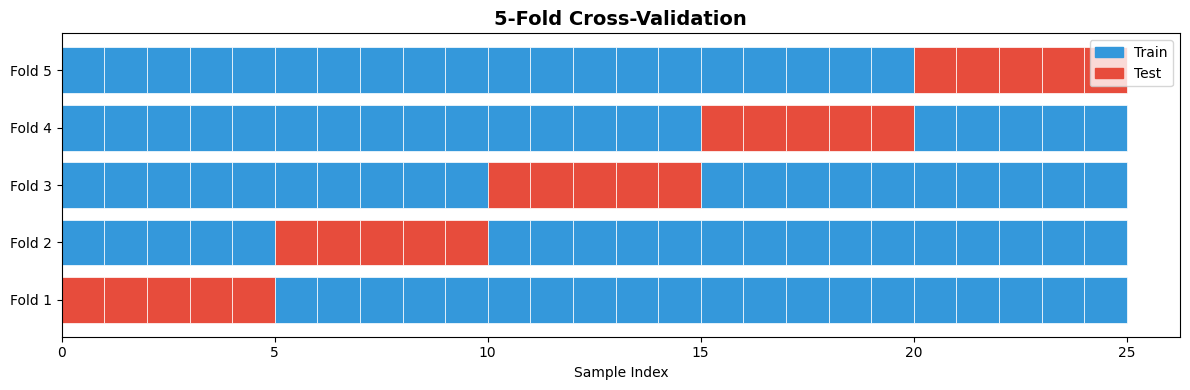


5-Fold CV Accuracy: [0.86 0.88 0.81 0.82 0.85]
평균: 0.8440 ± 0.0258


In [4]:
# K-Fold Cross-Validation 시각화 및 실행
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# K-Fold 시각화
n_samples = 25
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=False)

fig, ax = plt.subplots(figsize=(12, 4))

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(range(n_samples))):
    # Train: 파란색, Test: 빨간색
    for idx in range(n_samples):
        color = '#e74c3c' if idx in test_idx else '#3498db'
        ax.barh(fold_idx, 1, left=idx, color=color, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(n_folds))
ax.set_yticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.set_xlabel('Sample Index')
ax.set_title('5-Fold Cross-Validation', fontsize=14, fontweight='bold')

# 범례
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Train'), Patch(color='#e74c3c', label='Test')],
          loc='upper right')
plt.tight_layout()
plt.show()

# cross_val_score 실행
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
model = LogisticRegression(max_iter=1000, random_state=42)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"\n5-Fold CV Accuracy: {scores}")
print(f"평균: {scores.mean():.4f} ± {scores.std():.4f}")

### 📝 실습 2-5 [중급] K-Fold CV 직접 구현

`KFold`를 사용하되, 루프를 직접 작성하여 각 fold에서 학습 → 평가 → 점수 저장을 수행하세요.

In [ ]:
# 실습 2-5: 빈칸을 채우세요
import numpy as np
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 데이터 생성
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(____)): # 빈칸: split에 전달할 데이터
    # 데이터 분할
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 모델 학습 (빈칸: fit 호출)
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(____, ____)

    # 평가 (빈칸: score 호출)
    score = model.score(____, ____)
    fold_scores.append(score)

    print(f"Fold {fold+1}: Accuracy = {score:.4f}")

# 평균 및 표준편차
mean_score = np.mean(fold_scores)
std_score = np.std(fold_scores)
print(f"\n📊 평균 Accuracy: {mean_score:.4f} ± {std_score:.4f}")

# 검증
assert len(fold_scores) == 5, "5개 fold에 대한 점수가 있어야 합니다"
assert all(0.7 < s <= 1.0 for s in fold_scores), "모든 fold의 accuracy가 0.7 이상이어야 합니다"
assert 0.7 < mean_score <= 1.0, "평균 accuracy가 합리적 범위에 있어야 합니다"

print("\n✅ 모든 테스트 통과!")

### 🏆 도전 문제 [고급] Part 2 통합: 전체 ML 파이프라인

와인 품질 데이터셋(`sklearn.datasets.load_wine`)을 사용하여 전체 ML 파이프라인을 구성하세요.

**단계:**
1. 데이터 로드 및 탐색
2. Train / Validation / Test 분할 (60/20/20)
3. 여러 모델(KNN, Logistic Regression, Ridge Classifier) 학습
4. Validation Set으로 최적 모델 선택
5. Test Set으로 최종 평가

> **힌트:** `StandardScaler`로 특징 스케일링을 하면 성능이 향상됩니다.

In [ ]:
# 🏆 도전 문제: 빈칸을 채우세요
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score

# Step 1: 데이터 로드
wine = load_wine()
X, y = wine.data, wine.target
print(f"데이터 크기: {X.shape}, 클래스 수: {len(np.unique(y))}")

# Step 2: Train(60%) / Validation(20%) / Test(20%) 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=____, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=____, random_state=42)

# Step 3: 스케일링
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Step 4: 여러 모델 학습 및 Validation 평가
models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=____),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
}

best_model_name = None
best_val_acc = 0

for name, model in models.items():
    model.fit(____, ____) # 빈칸: 스케일링된 학습 데이터 사용
    val_acc = accuracy_score(y_val, model.predict(____))
    print(f"{name}: Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_name = name

# Step 5: 최적 모델로 Test 평가
best_model = models[best_model_name]
test_acc = accuracy_score(y_test, best_model.predict(X_test_s))
print(f"\n🏆 최적 모델: {best_model_name}")
print(f"📊 Test Accuracy: {test_acc:.4f}")

# 검증
assert test_acc > 0.8, f"Test accuracy가 너무 낮습니다: {test_acc}"
assert best_model_name is not None

print("\n✅ 모든 테스트 통과!")

---
# Part 3: 지도학습 알고리즘 (Supervised Learning Algorithms)
---

## 3.1 K-Nearest Neighbors (KNN)

KNN은 **비모수적(non-parametric)**, **인스턴스 기반(instance-based)** 알고리즘입니다.

### 작동 원리

| 단계 | 설명 |
|:---|:---|
| **학습 단계** | 데이터를 그냥 저장 (Lazy Learning) |
| **예측 단계** | 1. 새로운 데이터와 모든 학습 데이터 사이의 **거리 계산** |
| | 2. **K개의 가장 가까운 이웃** 선택 |
| | 3. 분류: **다수결 투표** / 회귀: **평균값** |

### Hyperparameter K의 역할

- **K가 작을 때** (예: K=1): 모델이 복잡 → 과적합 위험
- **K가 클 때** (예: K=50): 모델이 단순 → 과소적합 위험
- 적절한 K를 찾는 것이 중요!

In [ ]:
# KNN Classification 결정 경계 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_blobs

# 2D 데이터 생성
X, y = make_blobs(n_samples=200, centers=3, cluster_std=1.5, random_state=42)

# KNN 학습
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# 결정 경계 시각화를 위한 메쉬 그리드
h = 0.3
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

# 새로운 점과 K개 이웃 표시
new_point = np.array([[0, 0]])
pred = knn.predict(new_point)
distances, indices = knn.kneighbors(new_point)

plt.scatter(new_point[0, 0], new_point[0, 1], c='red', s=200, marker='*', zorder=5, label=f'New (pred={pred[0]})')
for idx in indices[0]:
    plt.plot([new_point[0, 0], X[idx, 0]], [new_point[0, 1], X[idx, 1]],
             'r--', alpha=0.5, linewidth=1)
    plt.scatter(X[idx, 0], X[idx, 1], s=150, facecolors='none', edgecolors='red', linewidths=2)

plt.title('KNN Decision Boundary (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=12)
plt.colorbar(scatter)
plt.show()

### 🔗 AI 연결: KNN의 장단점과 차원의 저주 (Curse of Dimensionality)

| 장점 | 단점 |
|:---|:---|
| 간단하고 직관적 | 예측이 느림 (모든 데이터와 거리 계산) |
| 별도의 학습 과정 불필요 | 메모리 사용량이 큼 |
| 비선형 결정 경계 가능 | 고차원에서 성능 저하 (**차원의 저주**) |

**차원의 저주:** 차원이 높아질수록 데이터가 희소(sparse)해지고, 모든 점들이 비슷한 거리에 위치하게 됩니다.  
→ "가장 가까운 이웃"이 의미가 없어짐!

In [ ]:
# 차원의 저주: 차원 증가에 따른 두 점 사이 거리 변화
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
dimensions = list(range(1, 101))
n_pairs = 100

mean_distances = []
std_distances = []

for dim in dimensions:
    # [0, 1]^d 공간에서 랜덤 점 생성
    points = np.random.uniform(0, 1, size=(n_pairs * 2, dim))
    dists = np.sqrt(np.sum((points[:n_pairs] - points[n_pairs:]) ** 2, axis=1))
    mean_distances.append(np.mean(dists))
    std_distances.append(np.std(dists))

plt.figure(figsize=(10, 6))
plt.plot(dimensions, mean_distances, 'b-', linewidth=2, label='Mean Distance')
plt.fill_between(dimensions,
                 np.array(mean_distances) - np.array(std_distances),
                 np.array(mean_distances) + np.array(std_distances),
                 alpha=0.2, color='blue', label='±1 Std Dev')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Euclidean Distance Between Two Points', fontsize=12)
plt.title('Curse of Dimensionality: Distance Increases with Higher Dimensions', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### 📝 실습 3-1 [초급] KNN으로 Iris 데이터 분류하기

Iris 데이터셋을 사용하여 KNN (K=3)으로 분류하세요.

In [ ]:
# 실습 3-1: 빈칸을 채우세요
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN 모델 생성 (빈칸: K=3 설정)
knn = KNeighborsClassifier(n_neighbors=____)

# 학습 (빈칸: fit 호출)
knn.fit(____, ____)

# 평가 (빈칸: score 호출)
train_acc = knn.score(X_train, y_train)
test_acc = knn.score(____, ____)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# 검증
assert test_acc > 0.9, f"Test accuracy가 0.9 이상이어야 합니다: {test_acc}"
assert knn.n_neighbors == 3, "K=3이어야 합니다"

print("\n✅ 모든 테스트 통과!")

### 📝 실습 3-2 [중급] K값 변화에 따른 결정경계 시각화

K = [1, 3, 5, 11, 21]에 대해 결정경계를 그리고, 각 K에 대한 Train/Test Accuracy를 기록하세요.

In [ ]:
# 실습 3-2: 빈칸을 채우세요
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 메쉬 그리드
h = 0.3
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

k_values = [1, 3, 5, 11, 21]
train_accs = []
test_accs = []

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, k in zip(axes, k_values):
    # 모델 생성 (빈칸: n_neighbors 설정)
    model = KNeighborsClassifier(n_neighbors=____)

    # 학습 (빈칸: fit 호출)
    model.fit(____, ____)

    # 예측 및 정확도 (빈칸: predict 호출)
    train_pred = model.predict(____)
    test_pred = model.predict(____)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # 결정 경계
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=30)
    ax.set_title(f'K={k}\nTrain: {train_acc:.3f} | Test: {test_acc:.3f}', fontsize=10)

plt.suptitle('KNN Decision Boundary by K Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 최적 K 찾기
best_k = k_values[np.argmax(test_accs)]
print(f"\n🏆 최적 K: {best_k} (Test Accuracy: {max(test_accs):.4f})")

# 검증
assert len(train_accs) == 5 and len(test_accs) == 5
assert train_accs[0] == 1.0 or train_accs[0] > 0.95, "K=1일 때 Training Accuracy가 매우 높아야 합니다"

print("\n✅ 모든 테스트 통과!")

## 3.2 Logistic Regression

이름은 **Regression**이지만, 실제로는 **분류(Classification)** 알고리즘입니다.

### Sigmoid (Logistic) 함수

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- 모든 실수를 **[0, 1]** 범위로 매핑 → **확률**로 해석 가능
- $z > 0$이면 $\sigma(z) > 0.5$ → **양성(Positive)** 클래스
- $z < 0$이면 $\sigma(z) < 0.5$ → **음성(Negative)** 클래스
- $z = w^T x + b$ (선형 결합)

### 결정 경계 (Decision Boundary)

$$\sigma(z) = 0.5 \Leftrightarrow z = 0 \Leftrightarrow w^T x + b = 0$$

→ 결정 경계는 입력 공간의 **초평면(hyperplane)**

In [ ]:
# Sigmoid 함수 시각화
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), 'b-', linewidth=3, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='y = 0.5')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='z = 0')
plt.scatter([0], [0.5], c='red', s=100, zorder=5)

# 영역 표시
plt.fill_between(z[z > 0], sigmoid(z[z > 0]), 0.5, alpha=0.1, color='green')
plt.fill_between(z[z < 0], sigmoid(z[z < 0]), 0.5, alpha=0.1, color='red')
plt.text(5, 0.8, 'Positive Class\n(σ > 0.5)', fontsize=12, ha='center', color='green')
plt.text(-5, 0.2, 'Negative Class\n(σ < 0.5)', fontsize=12, ha='center', color='red')

plt.xlabel('z', fontsize=14)
plt.ylabel('σ(z)', fontsize=14)
plt.title('Sigmoid (Logistic) Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.show()

In [ ]:
# Logistic Regression 이진 분류 예제
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 2D 이진 분류 데이터 생성
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression 학습
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

print(f"Training Accuracy: {lr.score(X_train, y_train):.4f}")
print(f"Test Accuracy:     {lr.score(X_test, y_test):.4f}")

# 결정 경계 시각화
h = 0.05
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', label='Class 0', edgecolors='k', s=60)
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='red', label='Class 1', edgecolors='k', s=60)
plt.title('Logistic Regression Decision Boundary', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=12)
plt.show()

### 🔗 AI 연결: Sigmoid → 신경망의 활성화 함수

Sigmoid는 신경망의 **활성화 함수(Activation Function)**로 사용됩니다.  
하지만 현대 딥러닝에서는 **ReLU**를 주로 사용하고, 출력층에서는 **Sigmoid**(이진 분류) 또는 **Softmax**(다중 분류)를 사용합니다.

In [ ]:
# Sigmoid, Tanh, ReLU 비교 시각화
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)

sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sigmoid
axes[0].plot(z, sigmoid, 'b-', linewidth=2)
axes[0].set_title('Sigmoid', fontsize=14, fontweight='bold')
axes[0].set_ylim(-0.5, 1.5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].text(2, 0.3, 'Output: [0, 1]\nBinary classification', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Tanh
axes[1].plot(z, tanh, 'g-', linewidth=2)
axes[1].set_title('Tanh', fontsize=14, fontweight='bold')
axes[1].set_ylim(-1.5, 1.5)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].text(1.5, -0.7, 'Output: [-1, 1]\nUsed in RNNs', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# ReLU
axes[2].plot(z, relu, 'r-', linewidth=2)
axes[2].set_title('ReLU', fontsize=14, fontweight='bold')
axes[2].set_ylim(-0.5, 5.5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[2].grid(True, alpha=0.3)
axes[2].text(1.5, 1, 'Output: [0, ∞)\nDefault in modern DL', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

for ax in axes:
    ax.set_xlabel('z', fontsize=12)
    ax.set_ylabel('f(z)', fontsize=12)

plt.suptitle('Comparison of Activation Functions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 실습 3-3 [초급] Sigmoid 함수 구현

NumPy로 Sigmoid 함수를 직접 구현하세요.

In [ ]:
# 실습 3-3: 빈칸을 채우세요
import numpy as np

def my_sigmoid(z):
    """Sigmoid 함수 구현"""
    return 1 / (1 + np.exp(-____))

# 테스트
print(f"sigmoid(0)   = {my_sigmoid(0):.4f}")
print(f"sigmoid(10)  = {my_sigmoid(10):.4f}")
print(f"sigmoid(-10) = {my_sigmoid(-10):.4f}")
print(f"sigmoid(100) = {my_sigmoid(100):.4f}")

# 검증
assert my_sigmoid(0) == 0.5, "sigmoid(0)은 0.5여야 합니다"
assert abs(my_sigmoid(10) - 1.0) < 0.001, "sigmoid(10)은 약 1.0이어야 합니다"
assert abs(my_sigmoid(-10)) < 0.001, "sigmoid(-10)은 약 0.0이어야 합니다"
assert my_sigmoid(100) > 0.99, "sigmoid(100)은 1에 매우 가까워야 합니다"

# 배열 입력 테스트
z_array = np.array([-2, -1, 0, 1, 2])
result = my_sigmoid(z_array)
assert len(result) == 5, "배열 입력에 대해 배열 출력을 반환해야 합니다"
assert np.all(result >= 0) and np.all(result <= 1), "출력이 [0, 1] 범위에 있어야 합니다"

print("\n✅ 모든 테스트 통과!")

### 📝 실습 3-4 [중급] Logistic Regression으로 유방암 분류

유방암 데이터셋(`sklearn.datasets.load_breast_cancer`)을 사용하여 Logistic Regression으로 분류하고,
Accuracy와 Confusion Matrix를 출력하세요.

In [ ]:
# 실습 3-4: 빈칸을 채우세요
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 데이터 로드
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
print(f"데이터 크기: {X.shape}")
print(f"클래스: {cancer.target_names}")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=____, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 모델 학습 (빈칸: fit 호출)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(____, ____)

# 예측 (빈칸: predict 호출)
y_pred = model.predict(____)

# 평가
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {acc:.4f}")
print(f"\nConfusion Matrix:")
print(cm)
print(f"  - True Negative (정상→정상):  {cm[0,0]}")
print(f"  - False Positive (정상→악성): {cm[0,1]}")
print(f"  - False Negative (악성→정상): {cm[1,0]}")
print(f"  - True Positive (악성→악성):  {cm[1,1]}")

# 검증
assert acc > 0.9, f"Accuracy가 0.9 이상이어야 합니다: {acc}"
assert cm.shape == (2, 2), "Confusion Matrix는 2x2여야 합니다"

print("\n✅ 모든 테스트 통과!")

---
# Part 4: 경사 하강법 (Gradient Descent)
---

## 4.1 Gradient Descent 원리

### 직관

산에서 가장 가파른 방향으로 한 걸음씩 내려가면 골짜기(최솟값)에 도달할 수 있습니다.

### 수식

$$w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial w}$$

| 기호 | 의미 |
|:---|:---|
| $w$ | 파라미터 (가중치) |
| $\alpha$ | **Learning Rate** (보폭) |
| $\frac{\partial L}{\partial w}$ | **Gradient** (기울기, 손실함수의 미분) |

- **Gradient**: 함수가 **가장 빠르게 증가하는 방향**
- **음의 방향**으로 이동 → 함수값이 감소 → **최솟값**을 향해 이동

In [ ]:
# 1D 함수에서 Gradient Descent 시각화
import numpy as np
import matplotlib.pyplot as plt

# 함수: f(x) = x^2
def f(x):
    return x ** 2

def df(x):
    return 2 * x  # f'(x) = 2x

# Gradient Descent
x = 4.0  # 시작점
lr = 0.3  # Learning Rate
history = [x]

for i in range(15):
    gradient = df(x)
    x = x - lr * gradient
    history.append(x)

# 시각화
x_range = np.linspace(-5, 5, 200)

plt.figure(figsize=(10, 6))
plt.plot(x_range, f(x_range), 'b-', linewidth=2, label='$f(x) = x^2$')

# GD 경로
for i in range(len(history) - 1):
    plt.scatter(history[i], f(history[i]), c='red', s=100, zorder=5)
    plt.annotate(f'Step {i}', (history[i], f(history[i])),
                 textcoords="offset points", xytext=(10, 10), fontsize=8)
    plt.arrow(history[i], f(history[i]),
              history[i+1] - history[i], f(history[i+1]) - f(history[i]),
              head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)

plt.scatter(history[-1], f(history[-1]), c='green', s=200, marker='*', zorder=5, label=f'Final: x={history[-1]:.4f}')
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x)', fontsize=14)
plt.title(f'Gradient Descent on f(x) = x² (lr={lr})', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"시작점: x = 4.0")
print(f"최종점: x = {history[-1]:.6f}")
print(f"최솟값: f(x) = {f(history[-1]):.6f}")

### 📝 실습 4-1 [초급] 단순 함수의 최솟값 찾기

$f(x) = (x - 3)^2 + 2$ 의 최솟값을 Gradient Descent로 찾으세요.

- 도함수: $f'(x) = 2(x - 3)$
- 최솟값: $x = 3$일 때 $f(x) = 2$

In [ ]:
# 실습 4-1: 빈칸을 채우세요
import numpy as np

# 함수 및 도함수
def f(x):
    return (x - 3) ** 2 + 2

def df(x):
    return 2 * (x - 3)

# Gradient Descent 설정
x = 10.0  # 시작점
lr = 0.1  # Learning Rate
n_steps = 20

print(f"시작: x = {x:.4f}, f(x) = {f(x):.4f}")

for i in range(n_steps):
    # Gradient 계산 (빈칸: 도함수 호출)
    gradient = ____

    # 업데이트 (빈칸: GD update rule)
    x = ____

    if (i + 1) % 5 == 0:
        print(f"Step {i+1:2d}: x = {x:.4f}, f(x) = {f(x):.4f}")

print(f"\n최종: x = {x:.4f}, f(x) = {f(x):.4f}")

# 검증: x가 3에 충분히 가까운지
assert abs(x - 3) < 0.1, f"x가 3에 충분히 가깝지 않습니다: x = {x}"
assert abs(f(x) - 2) < 0.1, f"f(x)가 2에 충분히 가깝지 않습니다: f(x) = {f(x)}"

print("\n✅ 모든 테스트 통과!")

### 📝 실습 4-2 [중급] Learning Rate에 따른 수렴 관찰

다양한 Learning Rate에 대해 GD를 수행하고, 수렴 과정을 비교하세요.  
특히 lr이 너무 크면(1.1) **발산**하는 것을 관찰하세요.

In [ ]:
# 실습 4-2: 빈칸을 채우세요
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x ** 2

def df(x):
    return 2 * x

learning_rates = [0.01, 0.1, 0.5, 0.9, 1.1]
n_steps = 20
x_start = 4.0

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
x_range = np.linspace(-6, 6, 200)

for ax, lr in zip(axes, learning_rates):
    x = x_start
    history = [x]

    for i in range(n_steps):
        # Gradient 계산
        gradient = df(x)

        # 업데이트 (빈칸: GD update rule)
        x = ____

        # 발산 방지 (값이 너무 커지면 중단)
        if abs(x) > 100:
            break
        history.append(x)

    # 시각화
    ax.plot(x_range, f(x_range), 'b-', linewidth=2)
    history_arr = np.array(history)
    ax.scatter(history_arr, f(history_arr), c='red', s=50, zorder=5)
    ax.plot(history_arr, f(history_arr), 'r--', alpha=0.5)

    converged = abs(history[-1]) < 0.5 if len(history) > 1 else False
    status = '수렴 ✓' if converged else '발산 ✗'
    ax.set_title(f'lr = {lr}\n{status}', fontsize=12, fontweight='bold')
    ax.set_ylim(-1, 20)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Descent Convergence by Learning Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ 시각화 완료! lr이 너무 크면 발산하는 것을 확인하세요.")

## 4.2 GD의 도전과제

### Local Minima와 Saddle Point

| 문제 | 설명 |
|:---|:---|
| **Local Minima** | 전역 최솟값(Global Minimum)이 아닌 **지역 최솟값**에 갇힘 |
| **Saddle Point** | 어떤 방향에서는 최솟값, 다른 방향에서는 최댓값 → 기울기가 0이지만 최솟값이 아님 |

### 해결 방안

- 적절한 Learning Rate 설정
- **SGD (Stochastic Gradient Descent)**: 미니배치로 노이즈를 추가하여 지역 최솟값 탈출
- **Momentum**: 이전 기울기의 관성 활용
- **Adam**: Adaptive Moment Estimation — 현재 가장 널리 사용되는 옵티마이저

In [ ]:
# 다중 극소점 함수에서 시작점에 따른 수렴 차이
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x * np.sin(x)

def df(x):
    return np.sin(x) + x * np.cos(x)

x_range = np.linspace(-10, 10, 500)
start_points = [-8, -3, 1, 5, 8]
lr = 0.01
n_steps = 300

plt.figure(figsize=(12, 6))
plt.plot(x_range, f(x_range), 'b-', linewidth=2, label='f(x) = x·sin(x)')

colors = ['red', 'green', 'orange', 'purple', 'brown']

for start, color in zip(start_points, colors):
    x = start
    history = [x]

    for _ in range(n_steps):
        x = x - lr * df(x)
        history.append(x)

    plt.scatter(start, f(start), c=color, s=100, marker='^', zorder=5)
    plt.scatter(history[-1], f(history[-1]), c=color, s=150, marker='*', zorder=5,
                label=f'Start={start:.0f} → Converge={history[-1]:.2f}')

plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Convergence by Starting Point (Local Minima)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

### 🔗 AI 연결: SGD, Adam 등 최적화 알고리즘

PyTorch의 `torch.optim`에서 다양한 옵티마이저를 제공합니다.

| 옵티마이저 | 특징 |
|:---|:---|
| **SGD** | 기본 확률적 경사 하강법 |
| **SGD + Momentum** | 관성을 추가하여 빠른 수렴 |
| **Adam** | Adaptive Learning Rate + Momentum → 가장 널리 사용 |
| **AdamW** | Adam + Weight Decay (현대 Transformer에서 주로 사용) |

In [ ]:
# PyTorch로 간단한 최적화 문제: SGD vs Adam 비교
import torch
import matplotlib.pyplot as plt

# 목표: f(x) = (x - 3)^2 + (y - 2)^2 의 최솟값 찾기
def run_optimizer(optimizer_class, lr, n_steps=100, **kwargs):
    x = torch.tensor([10.0], requires_grad=True)
    y = torch.tensor([10.0], requires_grad=True)
    optimizer = optimizer_class([x, y], lr=lr, **kwargs)

    history = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = (x - 3) ** 2 + (y - 2) ** 2
        loss.backward()
        optimizer.step()
        history.append((x.item(), y.item(), loss.item()))
    return history

# SGD vs Adam
sgd_history = run_optimizer(torch.optim.SGD, lr=0.1)
adam_history = run_optimizer(torch.optim.Adam, lr=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
axes[0].plot([h[2] for h in sgd_history], 'b-', linewidth=2, label='SGD (lr=0.1)')
axes[0].plot([h[2] for h in adam_history], 'r-', linewidth=2, label='Adam (lr=0.5)')
axes[0].set_xlabel('Step', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curve Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 경로 시각화
import numpy as np
xx, yy = np.meshgrid(np.linspace(-1, 12, 100), np.linspace(-1, 12, 100))
zz = (xx - 3) ** 2 + (yy - 2) ** 2
axes[1].contour(xx, yy, zz, levels=30, alpha=0.5, cmap='viridis')
axes[1].plot([h[0] for h in sgd_history], [h[1] for h in sgd_history], 'bo-', markersize=3, label='SGD', alpha=0.7)
axes[1].plot([h[0] for h in adam_history], [h[1] for h in adam_history], 'ro-', markersize=3, label='Adam', alpha=0.7)
axes[1].scatter([3], [2], c='green', s=200, marker='*', zorder=5, label='Minimum (3, 2)')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Optimization Path Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

### 📝 실습 4-3 [중급] 시작점에 따른 수렴 결과 비교

$f(x) = x^4 - 4x^2 + x$ 같은 다중 극소점 함수에서 여러 시작점으로 GD를 수행하고,
어디로 수렴하는지 관찰하세요.

- 도함수: $f'(x) = 4x^3 - 8x + 1$

In [ ]:
# 실습 4-3: 빈칸을 채우세요
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 4*x**2 + x

def df(x):
    return 4*x**3 - 8*x + 1

# 시작점들
start_points = [-2.5, -1.0, 0.0, 1.0, 2.5]
lr = 0.01
n_steps = 200

x_range = np.linspace(-3, 3, 500)

plt.figure(figsize=(12, 7))
plt.plot(x_range, f(x_range), 'b-', linewidth=2, label='$f(x) = x^4 - 4x^2 + x$')

colors = ['red', 'green', 'orange', 'purple', 'brown']
results = {}

for start, color in zip(start_points, colors):
    x = start
    history = [x]

    for _ in range(n_steps):
        # Gradient 계산 (빈칸: 도함수 호출)
        gradient = ____

        # 업데이트 (빈칸: GD update rule)
        x = ____

        history.append(x)

    results[start] = history[-1]

    # 시작점과 수렴점 표시
    plt.scatter(start, f(start), c=color, s=100, marker='^', zorder=5)
    plt.scatter(history[-1], f(history[-1]), c=color, s=150, marker='*', zorder=5,
                label=f'Start={start:.1f} → Converge={history[-1]:.2f}')

plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Convergence by Starting Point (Multiple Local Minima)', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 결과 출력
print("\n📊 수렴 결과:")
for start, final in results.items():
    print(f"  시작점 {start:5.1f} → 수렴점 {final:7.4f} (f(x) = {f(final):.4f})")

# 검증: 모든 수렴점에서 기울기가 거의 0인지 확인
for start, final in results.items():
    assert abs(df(final)) < 0.5, f"시작점 {start}에서 수렴이 완료되지 않았습니다"

print("\n✅ 모든 테스트 통과!")

### 🏆 도전 문제 [고급] 선형 회귀를 Gradient Descent로 직접 구현

NumPy만으로 선형 회귀를 Gradient Descent로 학습하세요.

**목표:** $y = 3x + 2 + \text{noise}$ 데이터에서 $w \approx 3$, $b \approx 2$를 학습

**단계:**
1. 데이터 생성: $y = 3x + 2 + \epsilon$
2. 손실함수: $\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$
3. Gradient 계산:
   - $\frac{\partial \text{MSE}}{\partial w} = \frac{-2}{n} \sum x_i (y_i - \hat{y}_i)$
   - $\frac{\partial \text{MSE}}{\partial b} = \frac{-2}{n} \sum (y_i - \hat{y}_i)$
4. GD로 w, b 업데이트 (200 epoch)
5. Loss 변화 시각화

In [ ]:
# 🏆 도전 문제: 빈칸을 채우세요
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 데이터 생성 (y = 3x + 2 + noise)
np.random.seed(42)
n_samples = 100
X = np.random.uniform(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)

# Step 2: 파라미터 초기화
w = 0.0  # 가중치
b = 0.0  # 편향
lr = 0.01  # Learning Rate
n_epochs = 200

losses = []
w_history = []
b_history = []

# Step 3: Gradient Descent
for epoch in range(n_epochs):
    # 예측 (빈칸: y_hat = w*X + b)
    y_hat = ____

    # 손실 계산: MSE (빈칸: MSE 공식)
    loss = np.mean((y - ____) ** 2)
    losses.append(loss)

    # Gradient 계산 (빈칸: dw, db 공식)
    dw = (-2 / n_samples) * np.sum(X * (y - y_hat))
    db = (-2 / n_samples) * np.sum(____)

    # 파라미터 업데이트 (빈칸: GD update rule)
    w = w - lr * ____
    b = b - lr * ____

    w_history.append(w)
    b_history.append(b)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.4f}, w = {w:.4f}, b = {b:.4f}")

print(f"\n최종 결과: w = {w:.4f} (목표: 3), b = {b:.4f} (목표: 2)")

# Step 4: 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss 곡선
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# w, b 변화
axes[1].plot(w_history, 'r-', linewidth=2, label=f'w (final: {w:.3f})')
axes[1].plot(b_history, 'g-', linewidth=2, label=f'b (final: {b:.3f})')
axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Target w=3')
axes[1].axhline(y=2, color='green', linestyle='--', alpha=0.5, label='Target b=2')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Parameter Value', fontsize=12)
axes[1].set_title('w, b Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 최종 회귀선
axes[2].scatter(X, y, alpha=0.5, label='Data', edgecolors='k')
X_sorted = np.sort(X)
axes[2].plot(X_sorted, w * X_sorted + b, 'r-', linewidth=3, label=f'y = {w:.2f}x + {b:.2f}')
axes[2].plot(X_sorted, 3 * X_sorted + 2, 'g--', linewidth=2, label='True: y = 3x + 2')
axes[2].set_xlabel('X', fontsize=12)
axes[2].set_ylabel('y', fontsize=12)
axes[2].set_title('Learned Regression Line', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 5: 검증
assert abs(w - 3) < 0.5, f"w가 3에 가깝지 않습니다: w = {w}"
assert abs(b - 2) < 0.5, f"b가 2에 가깝지 않습니다: b = {b}"
assert losses[-1] < losses[0], "Loss가 감소해야 합니다"

print("\n✅ 모든 테스트 통과! 선형 회귀를 GD로 성공적으로 구현했습니다!")

---
## 📋 핵심 개념 정리 (Summary)

| ML 개념 | 핵심 내용 | DL에서의 역할 |
|:---|:---|:---|
| **Supervised Learning** | 입력-출력 쌍으로 학습 | 신경망 학습의 기본 |
| **Train/Test Split** | 일반화 성능 평가 | 모든 DL 실험의 기본 |
| **Overfitting** | 학습 데이터에 과적합 | Dropout, Early Stopping으로 방지 |
| **Regularization** | 모델 복잡도 제한 | Weight Decay (L2) |
| **Cross-Validation** | 안정적 모델 평가 | 하이퍼파라미터 튜닝 |
| **KNN** | 거리 기반 분류/회귀 | 임베딩 공간에서의 유사도 |
| **Logistic Regression** | Sigmoid로 확률 출력 | 출력층 활성화 함수 |
| **Gradient Descent** | 손실함수 최소화 | 신경망 학습의 핵심 |
| **Learning Rate** | 학습 보폭 | 가장 중요한 하이퍼파라미터 |
| **NFL Theorem** | 만능 알고리즘은 없다 | 문제에 맞는 아키텍처 선택 |

### 핵심 수식 모음

| 수식 | 설명 |
|:---|:---|
| $\sigma(z) = \frac{1}{1+e^{-z}}$ | Sigmoid 함수 |
| $w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial w}$ | Gradient Descent 업데이트 |
| $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ | 평균 제곱 오차 |
| $\text{Loss} + \lambda \sum w_i^2$ | L2 정규화 (Ridge) |

> **핵심:** 딥러닝 = ML의 확장! 오늘 배운 개념들(데이터 분할, 과적합, 정규화, 경사하강법)은 딥러닝에서도 그대로 적용됩니다.

### Traditional ML vs Deep Learning 비교

| | Traditional ML | Deep Learning |
|:---|:---|:---|
| **특징 추출** | 사람이 직접 설계 (Feature Engineering) | 모델이 자동 학습 (Representation Learning) |
| **데이터 양** | 적은 데이터에서도 OK | 대량 데이터 필요 |
| **해석 가능성** | 비교적 높음 | 블랙박스 (설명 가능 AI 연구 중) |
| **계산 비용** | 낮음 (CPU 충분) | 높음 (GPU/TPU 필요) |
| **대표 알고리즘** | KNN, SVM, Decision Tree, Random Forest | CNN, RNN, Transformer |

---
## 🚀 더 알아보기 (Further Reading)

- [scikit-learn 공식 문서](https://scikit-learn.org/stable/)
- Understanding Deep Learning (Simon J.D. Prince) Ch 1-2
- [Dive into Deep Learning (d2l.ai)](https://d2l.ai/) Ch 1, 3

---

*End of Lab #04 — Basics of Machine Learning*